# Building a multilayer perceptron for classifying flowers in the iris dataset
Instead of building from scratch, we can use keras and build a two layer perceptron

In [15]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [16]:
# first get the dataset for the irirs, from tensorflow datasets
iris, iris_info = tfds.load('iris', with_info=True)
print(iris_info)

tfds.core.DatasetInfo(
    name='iris',
    full_name='iris/2.1.0',
    description="""
    This is perhaps the best known database to be found in the pattern recognition
    literature. Fisher's paper is a classic in the field and is referenced
    frequently to this day. (See Duda & Hart, for example.) The data set contains
    3 classes of 50 instances each, where each class refers to a type of iris
    plant. One class is linearly separable from the other 2; the latter are NOT
    linearly separable from each other.
    """,
    homepage='https://archive.ics.uci.edu/ml/datasets/iris',
    data_dir='/home/skramstad/tensorflow_datasets/iris/2.1.0',
    file_format=tfrecord,
    download_size=3.65 KiB,
    dataset_size=7.62 KiB,
    features=FeaturesDict({
        'features': Tensor(shape=(4,), dtype=float32),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('features', 'label'),
    disable_shuffling=False,
    nondeterministic_order=Fal

In [17]:
# have to split the in test and train ourself
# want to use two thirds as training
# spliting into train/test

tf.random.set_seed(1)
ds_orig = iris['train']
ds_orig = ds_orig.shuffle(150, reshuffle_each_iteration=False)

ds_train_orig = ds_orig.take(100)
ds_test = ds_orig.skip(100)

# convert dicitionary to tuple via map
ds_train_orig = ds_train_orig.map(lambda x: (x['features'], x['label']))

ds_test = ds_test.map(lambda x: (x['features'], x['label']))

In [18]:
# implementing the nn, with dense layer fully connected
# two hidden layers, the first recives input from four features, and project to 16 neurons
# second layer, recives output from those 16 neurons and project to 3 neurons, since we have three class labels
# this can be done usine sequential in keras

iris_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='sigmoid', name='fc1', input_shape=(4,)),

    tf.keras.layers.Dense(3, name='fc2', activation='softmax') # softmax in last layer since we have multi-class classification
]
)

iris_model.summary()

/home/skramstad/Documents/DAT300/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (Dense)                     │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# compile the model to specify the loss function, optimizer and the metrics for evaluation

iris_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

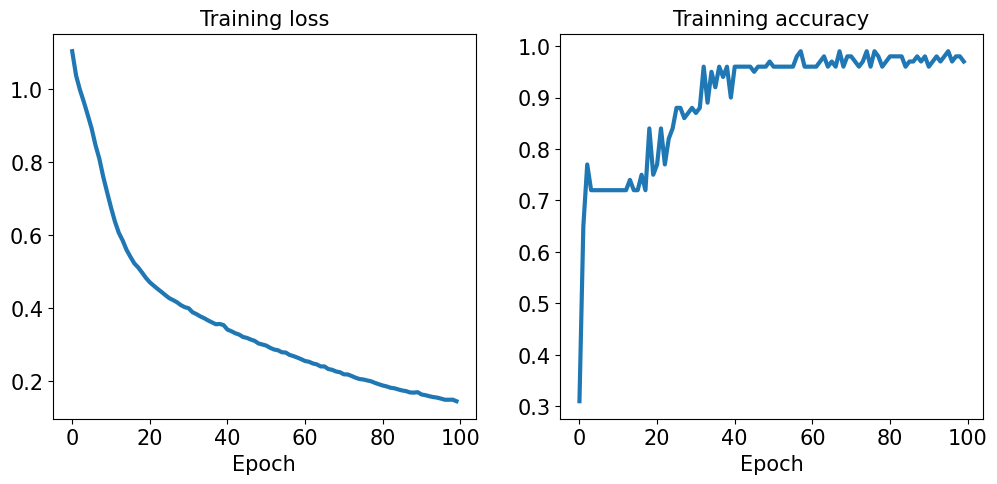

In [20]:
# now we can train the model
# define the number of epochs, batch size
# here we build an infinitely repeating dataset whihc will be passed to .fit() to train

num_epochs = 100
training_size = 100
batch_size = 2
steps_per_epochs = int(np.ceil(training_size/batch_size))

ds_train = ds_train_orig.shuffle(buffer_size=training_size)
ds_train = ds_train.repeat()
ds_train = ds_train.batch(batch_size=batch_size)
ds_train = ds_train.prefetch(buffer_size=1000)

history = iris_model.fit(ds_train, epochs=num_epochs,
                         steps_per_epoch=steps_per_epochs,
                         verbose=0)

hist = history.history

fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(1,2,1)
ax.plot(hist['loss'], lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1,2,2)
ax.plot(hist['accuracy'], lw=3)
ax.set_title('Trainning accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [21]:
# evalutaing the trained model on test dataset
# since we specified accuracy as elevation metric in .compile() we can directy evaluate on test data

results = iris_model.evaluate(ds_test.batch(50), verbose=0)
print('Test loss {:.4f} Test.Acc {:.4f}'.format(*results))

Test loss 0.1453 Test.Acc 0.9800


In [22]:
# saving and reloading the trained model
iris_model.save('iris-classifier.h5',
                overwrite=True,
                include_optimizer=True,
                save_format='h5')

In [23]:
# reload the saved model
# saved bot the model, weights and bias can easily rebuild
iris_model_new = tf.keras.models.load_model('iris-classifier.h5')

#verify by calling summary
iris_model_new.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (Dense)                     │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133 (536.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [24]:
# evaluate the reload model to verify results, on the test data
results = iris_model_new.evaluate(ds_test.batch(33), verbose=0)
print('Test loss {:.4f} Train.Acc {:.4f}'.format(*results))

Test loss 0.1453 Train.Acc 0.9800
